In [5]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [10]:
np_stars = df_stars.to_numpy()
np_stars = np.array(np_stars)
np_stars

array([[3068, 0.0024, 0.17, ..., 'Brown Dwarf', 'Red', 'M'],
       [3042, 0.0005, 0.1542, ..., 'Brown Dwarf', 'Red', 'M'],
       [2600, 0.0003, 0.102, ..., 'Brown Dwarf', 'Red', 'M'],
       ...,
       [8829, 537493.0, 1423.0, ..., 'Hypergiant', 'White', 'A'],
       [9235, 404940.0, 1112.0, ..., 'Hypergiant', 'White', 'A'],
       [37882, 294903.0, 1783.0, ..., 'Hypergiant', 'Blue', 'O']],
      dtype=object)

In [11]:
Temp = np.array(np_stars.T[0])
Lum = np.array(np_stars.T[1])
Rad = np.array(np_stars.T[2])
Mv = np.array(np_stars.T[3])
St = np.array(np_stars.T[4])
Sc = np.array(np_stars.T[5])
Spcl = np.array(np_stars.T[6])

Temp

array([3068, 3042, 2600, 2800, 1939, 2840, 2637, 2600, 2650, 2700, 3600,
       3129, 3134, 3628, 2650, 3340, 2799, 3692, 3192, 3441, 25000, 7740,
       7220, 8500, 16500, 12990, 8570, 7700, 11790, 7230, 39000, 30000,
       15276, 9700, 5800, 8052, 6757, 6380, 5936, 5587, 3826, 3365, 3270,
       3200, 3008, 3600, 3575, 3574, 3625, 33750, 3490, 3750, 3834, 3749,
       3650, 3450, 3660, 3450, 3752, 3535, 3341, 3432, 2983, 2835, 2935,
       3295, 2945, 2817, 2774, 2871, 3345, 3607, 3304, 3150, 3550, 3180,
       2890, 3342, 2621, 3158, 7100, 10574, 8930, 17200, 14100, 9675,
       12010, 10980, 13720, 19860, 5300, 4526, 4077, 4980, 9030, 11250,
       5112, 7720, 12098, 36108, 33300, 40000, 23000, 17120, 11096, 14245,
       24630, 12893, 24345, 33421, 3459, 3605, 3615, 3399, 3610, 3553,
       4015, 3625, 6850, 3780, 3323, 3531, 3218, 3146, 3511, 3225, 2935,
       2861, 2856, 2731, 3095, 3607, 3100, 2989, 3542, 3243, 3091, 3598,
       3324, 3541, 13420, 21020, 18290, 14520, 11900,

In [8]:
le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
St = le.fit_transform(St)
labels = le.inverse_transform(St)
class_names = le.classes_
print(class_names)
print(St)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']
[0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2
 2 2 2 4 4 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 3 3 3 3
 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 1
 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5
 5 5 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2 2 2 2 4 4
 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1]


In [22]:
BD = np.where(St=='Brown Dwarf')[0]
HG = np.where(St=='Hypergiant')[0]
MS = np.where(St=='Main Sequence')[0]
RD = np.where(St=='Red Dwarf')[0]
SG = np.where(St=='Supergiant')[0]
WD = np.where(St=='White Dwarf')[0]
startypes = [BD, HG, MS, RD, SG, WD]
colors = ['brown', 'purple', 'yellow', 'red', 'lightblue', 'grey']

In [24]:
for i in range(6): plt.scatter(Temp[startypes[i]], Lum[startypes[i]], c=colors[i], label=class_names[i])
plt.xscale('log')
plt.yscale('log')
plt.legend()

Error in callback <function _draw_all_if_interactive at 0x10f988400> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 640x480 with 1 Axes>

## Performing PCA

In [33]:
np.random.seed(22)
X = np.array([Temp, Lum, Rad, Mv]).T
print('sample', X.shape)
pca = PCA(n_components=2)
pca.fit(X)

X_pca = pca.transform(X)
mean = pca.mean_
eigvecs = pca.components_
print('sample pca', X_pca.shape)
print('mean', mean.shape)
print('eigvecs', eigvecs.shape)

sample (240, 4)
sample pca (240, 2)
mean (4,)
eigvecs (2, 4)


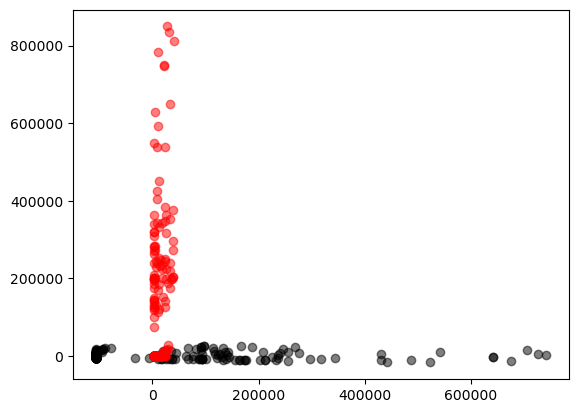

In [34]:
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, c='black')
plt.scatter(X[:,0], X[:,1], alpha=0.5, c='red')
#plt.xscale('log')
#plt.yscale('log')

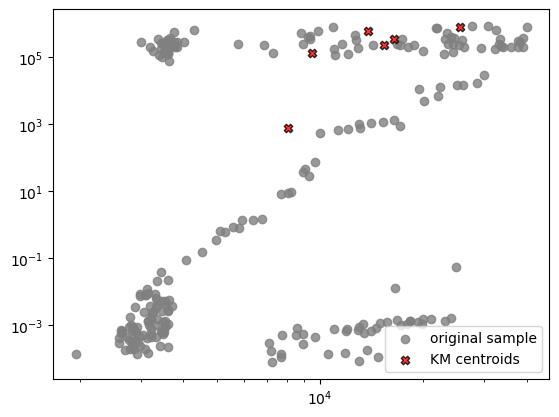

In [35]:
kmeans = KMeans(n_clusters=6, random_state=22, n_init="auto").fit(X) 
plt.scatter(X[:,0], X[:,1], c='grey', alpha=0.8, label='original sample')
plt.scatter(kmeans.cluster_centers_.T[0], kmeans.cluster_centers_.T[1], c='red', edgecolors='black', alpha=0.8, label='KM centroids', marker='X')
plt.xscale('log')
plt.yscale('log')
plt.legend()

Maybe massaging data can improve the analysis...

In [36]:
scaler = StandardScaler()
X = scaler.fit_transform(np.array([Temp, Lum, Rad, Mv]).T)
print('sample', X.shape)
pca = PCA(n_components=2)
pca.fit(X)

X_pca = pca.transform(X)
mean = pca.mean_
eigvecs = pca.components_
print('sample pca', X_pca.shape)
print('mean', mean.shape)
print('eigvecs', eigvecs.shape)

sample (240, 4)
sample pca (240, 2)
mean (4,)
eigvecs (2, 4)


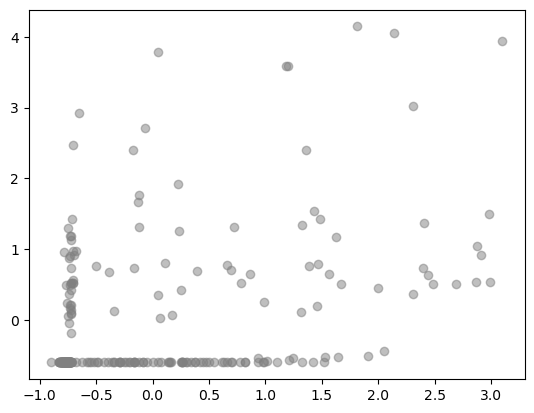

In [37]:
plt.scatter(X[:,0], X[:,1], c='grey', alpha=0.5)

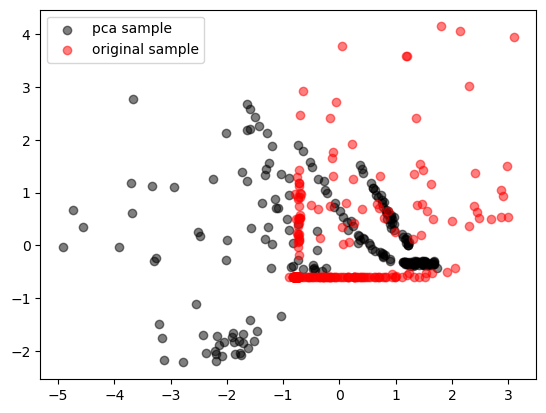

In [38]:
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, c='black', label='pca sample')
plt.scatter(X[:,0], X[:,1], alpha=0.5, c='red', label='original sample')
#plt.xscale('log')
#plt.yscale('log')
plt.legend(loc='upper left')

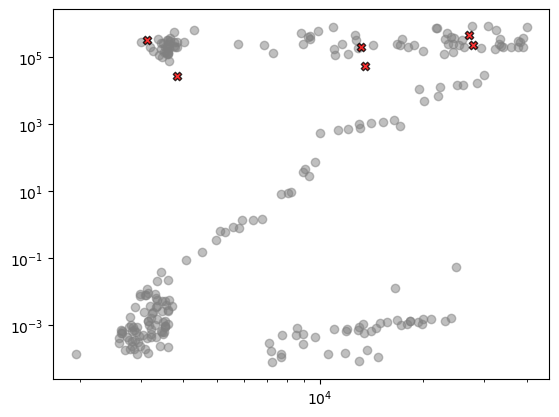

In [39]:
kmeans = KMeans(n_clusters=6, random_state=22, n_init="auto").fit(X_pca)
X = scaler.inverse_transform(X)
centroids_pca = kmeans.cluster_centers_
centroids = pca.inverse_transform(centroids_pca)
centroids = scaler.inverse_transform(centroids)
plt.scatter(X[:,0], X[:,1], alpha=0.5, c='grey', label='stars')
plt.scatter(centroids[:,0], np.abs(centroids[:,1]), c='red', edgecolors='black', alpha=0.8, label='KM centroids', marker='X')
plt.xscale('log')
plt.yscale('log')
#plt.legend()